<a href="https://colab.research.google.com/github/Shiyasalloor/Computer_Vision_Lab/blob/main/SIFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Remove conflicting versions
!pip uninstall -y opencv-python opencv-contrib-python numpy

# Install compatible versions
!pip install numpy==1.26.4
!pip install opencv-contrib-python==4.8.0.76


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires opencv-python>=3.4.8.29, which is not installed.
pytensor 2.36.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.

  Using cached opencv_contrib_python-4.8.0.76-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 7.7 MB/s eta 0:00:00


Keypoints in Image1: 1593
Keypoints in Image2: 1583
Good Matches after ratio test: 1460


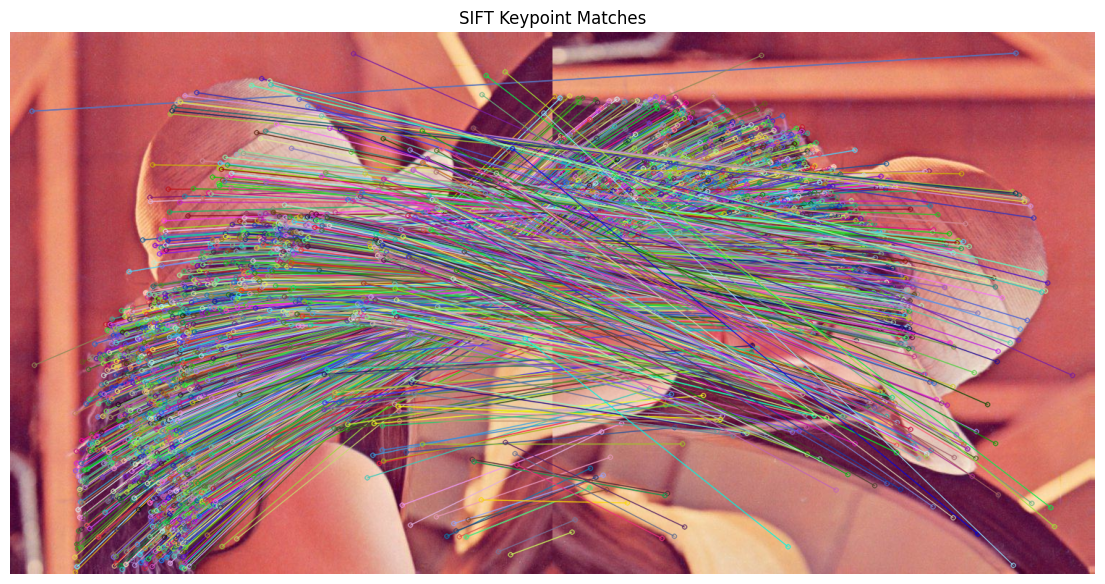

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load Images ----------
img1 = cv2.imread('/content/lana.jpeg')  # query image
img2 = cv2.rotate(img1, cv2.ROTATE_90_CLOCKWISE) # train image

# Convert to grayscale (SIFT works on gray)
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# ---------- Create SIFT object ----------
sift = cv2.SIFT_create()

# ---------- Detect keypoints and descriptors ----------
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

print(f"Keypoints in Image1: {len(kp1)}")
print(f"Keypoints in Image2: {len(kp2)}")

# ---------- Brute Force Matcher ----------
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

# KNN match (k=2 for ratio test)
matches = bf.knnMatch(des1, des2, k=2)

# ---------- Lowe's Ratio Test ----------
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print(f"Good Matches after ratio test: {len(good_matches)}")

# ---------- Draw Matches ----------
matched_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    good_matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# ---------- Show Result ----------
plt.figure(figsize=(14,8))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title("SIFT Keypoint Matches")
plt.axis('off')
plt.show()


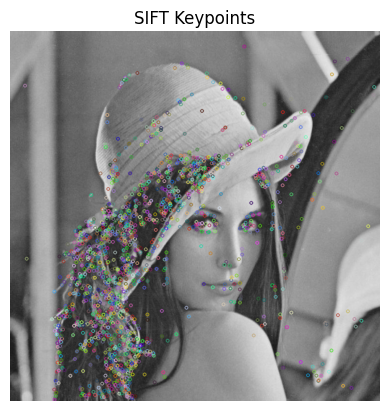

In [ ]:
kp_img = cv2.drawKeypoints(gray1, kp1, None)
plt.imshow(kp_img, cmap='gray')
plt.title("SIFT Keypoints")
plt.axis('off')
plt.show()
